## 01 EDA - Used Vehicle Price Prediction
**Alec Blevins**
**9/30/2026**

### Business Context

A used car dealership must decide what asking price to post for each vehicle in its inventory: too high and cars sit on the lot, too low and margin is lost. 

**Client question:** *"Given a vehicle's characteristics, what asking price is typical for comparable listings, and which attributes are associated with higher posted prices?"*

**Statistical Goals:**
1. Estimate a pricing model on Craigslist used-vehicle listings
2. Quantify how much each attribute contributes to posted price
3. Flag listings whose asking price deviates substantially from what comparable inventory posts

**Note on response variable:** The `price` field in this dataset is the seller's *asking price*, not the price at which the vehicle sold. This is a documented feature of Craigslist listing data. This does not prevent the analysis, but it does change the interpretation. Estimated coefficients describe how *posted* prices vary with vehicle characteristics, the implicit price of each attribute in listing behavior, rather than the market-clearing transaction price. 

### Purpose of this notebook
This notebook performs preliminary EDA on the Craigslist Used Vehicle Dataset (~427k listings). The goals are to: 
1. Profile the data (shape, types, null)
2. Identify data quality issues 
3. Characterize the target variable `price`
4. Motivate the finalized cleaning and feature-engineering pipeline that will produce the modeling subset 




### Imports & Load

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Data Import
df = pd.read_csv("C:\\Users\\alecp\\MyPrograms\\STA 334\\used_vehicle_prediction\\vehicle_data\\vehicles.csv", low_memory=False)

Considering the shape of the raw data:

In [8]:
print(df.shape)
df.sample(5, random_state=42)

(426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
100905,7315883828,https://lakeland.craigslist.org/ctd/d/lakeland...,lakeland,https://lakeland.craigslist.org,36990,2017.0,ford,f150 super cab lariat,good,6 cylinders,...,NaN,pickup,white,https://images.craigslist.org/00s0s_lRS7etJoVE...,Carvana is the safer way to buy a car During t...,NaN,fl,28.0400,-81.9600,2021-05-02T15:31:06-0400
143835,7314599643,https://quadcities.craigslist.org/ctd/d/waterl...,"quad cities, IA/IL",https://quadcities.craigslist.org,27995,2006.0,chevrolet,corvette,good,8 cylinders,...,NaN,convertible,black,https://images.craigslist.org/00101_aa4DyXpKu0...,2006 *** Chevrolet Corvette Convertible Conver...,NaN,il,42.4778,-92.3661,2021-04-29T18:46:35-0500
20235,7308399808,https://littlerock.craigslist.org/ctd/d/clinto...,little rock,https://littlerock.craigslist.org,78423,2015.0,chevrolet,corvette,NaN,8 cylinders,...,NaN,convertible,NaN,https://images.craigslist.org/00A0A_kJsL7mVMCg...,➔ Want to see more pictures?Paste this link to...,NaN,ar,38.4018,-93.7850,2021-04-17T14:01:33-0500
300734,7312663807,https://wheeling.craigslist.org/ctd/d/follansb...,northern panhandle,https://wheeling.craigslist.org,14000,2013.0,bmw,328i,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00K0K_2oCjTKrjd9...,"**Deals, Deals, Deals** Beautiful 2013 BMW 3-S...",NaN,oh,40.3203,-80.6250,2021-04-25T23:53:42-0400
316249,7315368523,https://eugene.craigslist.org/ctd/d/cottage-gr...,eugene,https://eugene.craigslist.org,676,2019.0,chevrolet,suburban ls,NaN,8 cylinders,...,NaN,NaN,black,https://images.craigslist.org/00H0H_3hFsa4lTxO...,2019 Chevrolet Suburban LS Brads Chevy - ☎️ ...,NaN,or,43.7839,-123.0529,2021-05-01T10:04:24-0700


Column types and non-null counts: 

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

Further investigating missing values: 

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct})

,missing,pct
county,426880,100.00
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93


Target Variable Investigation (Price): 

In [12]:
print(df["price"].describe())
print(df["price"].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64
0.001         0.0
0.010         0.0
0.050         0.0
0.500     13950.0
0.950     44500.0
0.990     66995.0
0.999    120000.0
Name: price, dtype: float64


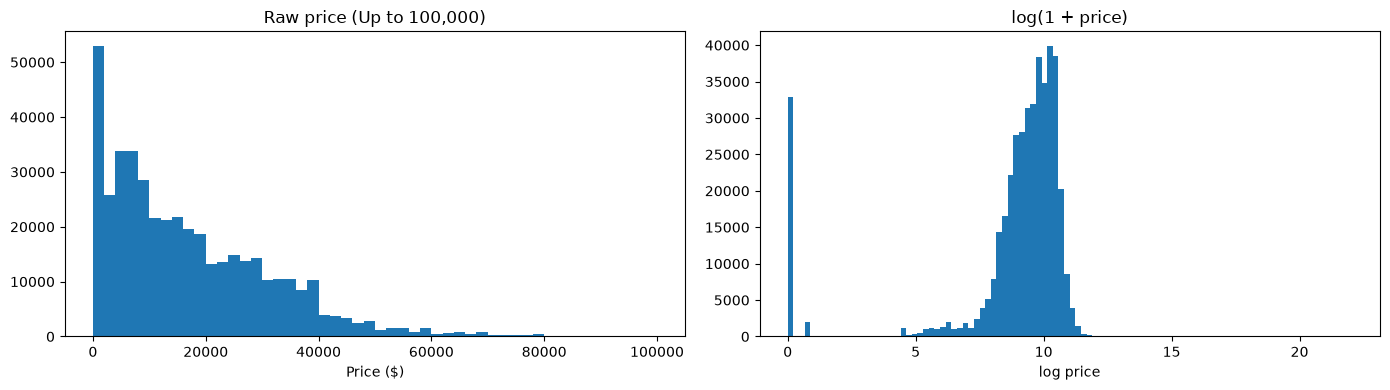

In [16]:
#Visualizing the distribution of `price`

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["price"], bins=50, range = (0, 100000))
axes[0].set_title("Raw price (Up to 100,000)")
axes[0].set_xlabel("Price ($)")

axes[1].hist(np.log1p(df["price"]), bins=100)
axes[1].set_title("log(1 + price)")
axes[1].set_xlabel("log price")

plt.tight_layout()
plt.show()

How many vehicles are free, $0? 

In [18]:
print((df["price"] == 0).sum())

32895


Investigating further, less than $100? What other strange values do we have? 

In [21]:
# How many zero or near-zero prices?
print("How many zero or near-zero prices?")
print((df["price"] <= 100).sum())

# Very high prices?
print("How many very high prices?")
print((df["price"] > 100_000).sum())

# Check odometer
print("Odometer statistics:")
print(df["odometer"].describe())
print("How many vehicles have zero odometer reading?")
print((df["odometer"] == 0).sum())

# Check year
print("Year statistics:")
print(df["year"].describe())
print("Most common years:")
print(df["year"].value_counts().head(20))

How many zero or near-zero prices?
36389
How many very high prices?
655
Odometer statistics:
count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64
How many vehicles have zero odometer reading?
1965
Year statistics:
count    425675.000000
mean       2011.235191
std           9.452120
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64
Most common years:
year
2017.0    36420
2018.0    36369
2015.0    31538
2013.0    30794
2016.0    30434
2014.0    30283
2019.0    25375
2012.0    23898
2011.0    20341
2020.0    19298
2008.0    17150
2010.0    15829
2007.0    14873
2006.0    12763
2009.0    12185
2005.0    10622
2004.0     8971
2003.0     7151
2002.0     5587
2001.0     4443
Name: count, dtype: int64


Investigating Categorical Columns: 

In [23]:
cat_cols = ["manufacturer", "condition", "cylinders", "fuel",
            "title_status", "transmission", "drive", "size",
            "type", "paint_color", "state"]

for c in cat_cols:
    print(f"\n--- {c} ---")
    print(f"n unique: {df[c].nunique()}")


--- manufacturer ---
n unique: 42

--- condition ---
n unique: 6

--- cylinders ---
n unique: 8

--- fuel ---
n unique: 5

--- title_status ---
n unique: 6

--- transmission ---
n unique: 3

--- drive ---
n unique: 3

--- size ---
n unique: 4

--- type ---
n unique: 13

--- paint_color ---
n unique: 12

--- state ---
n unique: 51


### Initial EDA Conclusions

The raw dataset contains 426,880 used-vehicle listings and 26 columns, with a highly right-skewed price distribution. Four findings drive the cleaning and feature-engineering decisions for the modeling phase. 

**First, the target requires filtering and transformation.** Roughly 7.7% of listings report a price of $0, and 8.5% report a price of $100 or less - values that are placeholders rather than true listings. At the opposite extreme, 655 listings exceed $100,000. The log-transformed price distribution is approximately symmetric, confirming that `log(price)` is the appropriate modeling scale, and that extreme outliers should be trimmed before fitting. 

**Second, several predictors have substantial missingness.** `county` is 100% missing and will be dropped outright. `size` (71.8%), `cylinders` (41.6%), `condition` (40.8%), `VIN` (37.7%), `drive` (30.6%), `paint_color` (30.5%), and `type` (21.8%) have enough missing entries that dropping rows would sacrifice a large fraction of the sample. Instead, missing values in categorical predictors will be retained as an explicit `"Unknown"` level, which allows the model to estimate whether missingness itself carries predictive information. However, this motivates another interesting point: 

**Third, text-based recovery of missing attributes.** Several categorical predictors with substantial missingness (`cylinders`, `drive`, `fuel`, etc.) may be recoverable from the free-text `description` field, which is 99.98% complete.

**Fourth, numeric predictors contain impossible values.** The odometer field has a maximum of 10,000,000 miles and 1,965 listings with zero miles - both implausible for a used vehicle. The remaining categorical predictors seem well-behaved. 

Together, these findings motivate a cleaning pipeline that (i) filters implausible prices, years, and odometer readings, (ii) retains categorical missingness as an explicit level, (iii) strips `description` and overrides missingness in attributes, and (iv) defines `log(price)` as the response. The resulting subset will be used to fit the pricing model in the next phase. 

In conclusion, this project deals with real, messy, user-inputted data. Postings contain many placeholders - prices of $0 or $1,234, model years of 1900, odometer readings of zero - that reflect how sellers actually fill out forms rather than any real vehicle. Many posts are also insufficiently detailed, leaving predictors such as `cylinders`, `drive`, and `condition` unanswered. Working with this dataset is therefore as much an exercise in data cleaning and judgment as it is in statistical modeling, and it mirrors the challenges of real-world listings data more broadly. 
